# Vodafone Music Subscription Prediction

## Sprint 1 - Initial Data Exploration

**Goal of this notebook:**

Perform initial data exploration to understand the dataset structure,
detect quality issues, and generate hypotheses for the cleaning stage.

**Notebook outline:**
1. Business Problem
2. Data Loading
3. Initial Data Inspection
4. Missing Values
5. Target Distribution
6. Correlation Analysis
7. Outlier Analysis
8. Key Features Visualization
9. Limitations & Next Steps

### 1. Business Problem

We predict whether a subscriber will purchase the **Music** service (binary classification).

**Target variable:**
- `1` — subscribed to Music service
- `0` — not subscribed

**Evaluation metric:** ROC-AUC (standard for imbalanced binary classification).

**Business impact:**

| Error type | Consequence |
|---|---|
| False Negative (miss a subscriber) | Lost revenue — we skip a paying customer |
| False Positive (wrong prediction) | Wasted marketing budget on a non-interested user |

> **Key consideration:** The dataset is expected to be imbalanced (far fewer subscribers than non-subscribers),
> so accuracy alone will be misleading. We must use ROC-AUC or F1-score as the primary metric.

### 2. Data Loading

Load dataset and check its basic structure.

In [1]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Downloading the dataset
DATA_PATH = '../data/raw/music.csv'
df = pd.read_csv(DATA_PATH)

### 3. Initial Data Inspection

We inspect:
- first rows
- dataset shape
- feature types

In [3]:
# Output the first 5 rows of the dataset
display(df.head())

# Print the dimension of a dataset
print(df.shape)

# Print dataset's data types
print(df.info())

,id,target,device_type,manufacturer_category,os_category,sim_count,tp_flag,lt,block_flag,days_exp,...,service_5_count_m3,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3,service_9_flag_m3
0,48104912810,0,7,1514,3,1.0,0,0.496508,0,299.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,13762.315646,1292.468784,NaN
1,4851497268,0,4,896,28,1.0,0,0.881540,0,189.0,...,11.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000053,NaN
2,4877823097,0,7,592,3,2.0,0,0.811192,0,347.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.000977,NaN
3,4830183791,0,7,1756,3,2.0,0,0.928449,1,343.0,...,66.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.006680,NaN
4,48103940036,0,4,1057,28,1.0,0,0.578654,0,355.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.002487,1.0


(70000, 461)
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 461 entries, id to service_9_flag_m3
dtypes: float64(452), int64(9)
memory usage: 246.2 MB
None


#### Dataset Overview

The dataset contains:
- **70,000 observations** (rows)
- **461 features** (columns), including the target variable

**Feature groups (based on Feature_dictionary.xlsx):**
- Device characteristics (`device_type`, `manufacturer_category`, `os_category`)
- General subscriber info (`lt`, `days_exp`, `sim_count`, `block_flag`, ...)
- Service usage flags and counts
- Temporal behavioral features with suffixes `_m1`, `_m2`, `_m3` (last 3 months)
- App usage, URL category traffic, SMS activity, campaign history

**Data types observed:**
- Most features are numeric (`int64` / `float64`)
- Categorical features (`device_type`, `os_category`, `manufacturer_category`) are label-encoded as integers
- No raw string columns detected

> **Note:** `manufacturer_category` has **479 unique values** — very high cardinality.
> Standard One-Hot Encoding is not applicable; Target Encoding or frequency grouping will be required during preprocessing.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,1.305400e+10,1.717707e+10,4.825641e+08,4.832763e+09,4.872800e+09,4.897161e+09,4.810871e+10
target,70000.0,7.572857e-02,2.645652e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
device_type,70000.0,6.532643e+00,1.201587e+00,1.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,8.000000e+00
manufacturer_category,70000.0,8.877520e+02,4.906140e+02,1.000000e+00,5.920000e+02,8.960000e+02,1.057000e+03,1.836000e+03
os_category,70000.0,7.693771e+00,9.540659e+00,1.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.800000e+01
...,...,...,...,...,...,...,...,...
income_brnd_cont_m3,9233.0,1.723460e+01,7.705491e+01,3.373000e-01,3.137200e+00,8.329400e+00,1.960800e+01,5.925717e+03
data_type_1_m3,8030.0,2.323908e+03,5.727355e+03,4.959106e-05,5.038317e+01,4.742066e+02,2.065807e+03,1.292934e+05
data_type_2_m3,44382.0,2.791410e+03,6.522942e+03,3.814697e-05,1.204510e+02,6.629353e+02,2.484430e+03,3.329914e+05
data_type_3_m3,49972.0,3.563612e+02,1.040861e+03,3.051758e-05,4.564953e+00,5.778860e+01,2.910770e+02,6.555479e+04


As seen in the table above, some features have maximum values that are thousands of times larger than the median. This confirms the presence of **outliers** (Whales/Super-users), which aligns with the "Power Law" distribution typical for telecom data.

### 4. Missing Values

In [5]:
# Calculating the mean number of missing values in columns
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(10))

# Displaying the number of columns in which the percentage of missing values exceeds 50%
print((missing > 0.5).sum())

count_url_category_13    0.992771
count_url_category_15    0.987029
vol_app_3                0.986643
count_app_3              0.986643
count_url_category_12    0.983129
vol_app_11               0.977329
count_app_11             0.977329
count_app_13             0.973143
vol_app_13               0.973143
count_url_category_1     0.972186
dtype: float64
62


#### Observations on Missing Values

Several features contain extremely high missing ratios (above 95%).

For example:
- `count_url_category_13` → 99.3% missing
- `vol_app_3` → 98.6% missing

Out of **461 total features**, **62 columns (~13%)** contain more than 50% missing values.
This indicates significant structural sparsity.

#### Imputation Strategy (preview)

After reviewing the feature dictionary, the following rules will be applied during cleaning:

| Feature type | Missing value meaning | Strategy |
|---|---|---|
| `count_*`, `vol_*`, `*_flag*` | No activity recorded | Fill with **0** |
| Continuous behavioral metrics | Missing observation | Fill with **median** |
| Constant/near-constant features | No information | **Drop** column |

> The approach is feature-semantic rather than a single global rule.

In [6]:
# Count the number of unique values for each column
unique_counts = df.nunique()

# Find constant columns (only 1 value) - candidates for deletion
constant_cols = unique_counts[unique_counts == 1].index.tolist()

# Find binary columns (only 2 values)
binary_cols = unique_counts[unique_counts == 2].index.tolist()

# Check the cardinality of the main categorical features
# (Even if they are encoded with numbers, it is important for us to know how many categories there are)
cat_features = ['device_type', 'manufacturer_category', 'os_category']

print(f"Total columns:  {df.shape[1]}")
print(f"Constant columns (1 unique value): {len(constant_cols)}")
if len(constant_cols) > 0:
    print(f"   Examples: {constant_cols[:5]}")

print(f"Binary columns (0/1 or True/False): {len(binary_cols)}")

print("\nCardinality of categorical features:")
for col in cat_features:
    if col in df.columns:
        print(f"   - {col}: {df[col].nunique()} unique values")
    else:
        print(f"   - {col}: not found in dataset")

# Display the distribution of unique values for device_type (as an example)
if 'device_type' in df.columns:
    print("\nDistribution of device_type (Top 5):")
    print(df['device_type'].value_counts(normalize=True).head(5))

Total columns:  461
Constant columns (1 unique value): 19
   Examples: ['service_2_flag', 'inact_days_count', 'rr_act_type_7', 'rr_gift_type_1', 'voice_omo_in_cost_m1']
Binary columns (0/1 or True/False): 10

Cardinality of categorical features:
   - device_type: 7 unique values
   - manufacturer_category: 479 unique values
   - os_category: 17 unique values

Distribution of device_type (Top 5):
device_type
7    0.819200
4    0.140000
8    0.023214
1    0.009986
6    0.005457
Name: proportion, dtype: float64


#### Observations on Unique Values & Cardinality

**Constant features (1 unique value):**
19 columns were identified with zero variance. These provide no information to any model
and will be removed in the cleaning stage.

**Binary features:**
10 columns contain exactly 2 unique values (typically `0` and `1`), consistent with
service flags and activity indicators.

**Categorical cardinality:**

| Feature | Unique values | Preprocessing implication |
|---|---|---|
| `device_type` | 7 | Low cardinality — One-Hot Encoding is fine |
| `os_category` | 17 | Manageable — One-Hot or frequency encoding |
| `manufacturer_category` | **479** | ⚠️ Very high — One-Hot not applicable, use Target Encoding or group rare values |

> For `device_type`, the top value (ID=7) represents **81.9%** of all records.
> Rare device type IDs may be grouped into an "Other" category during preprocessing.

### 5. Target Distribution

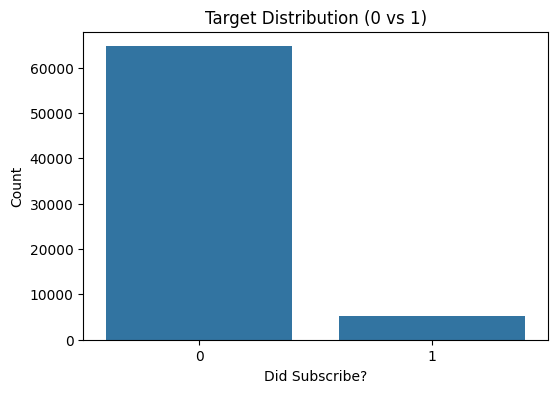

target
0    0.924271
1    0.075729
Name: proportion, dtype: float64
target
0    64699
1     5301
Name: count, dtype: int64


In [7]:
# Construction of a distribution graph of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=df['target'])
plt.title('Target Distribution (0 vs 1)')
plt.xlabel('Did Subscribe?')
plt.ylabel('Count')
plt.show()

# Calculation of the percentage ratio of subscribed customers (1) to unsubscribed customers (0)
print(df['target'].value_counts(normalize=True))

# Displaying the number of subscribed customers (1) and unsubscribed customers (0)
print(df['target'].value_counts())

#### Observations

The dataset is highly imbalanced.

- Class 0 (no subscription) represents 92.43% of the data.
- Class 1 (subscription) represents only 7.57%.

This indicates a strong class imbalance.

#### Implications

Accuracy will not be a reliable metric, as a naive model predicting only class 0 would achieve over 92% accuracy.

Therefore, evaluation metrics such as ROC-AUC, F1-score, and Recall will be more appropriate for this task.

Class imbalance handling techniques may be required during modeling.


### 6. Correlation Analysis

We compute **Pearson** correlation between all numerical features and the target variable.
Given the binary nature of the target, we also note that **point-biserial / Spearman correlation**
would be more appropriate for non-linear relationships — this will be applied in Sprint 2 EDA.

Here we use Pearson as a fast initial scan.

In [8]:
# Drop ID column for correlation analysis (not a feature)
df_corr = df.drop(columns=['id'], errors='ignore')

# Pearson correlation with target — dropna() to avoid NaN from constant features
pearson_corr = (
    df_corr.corr(numeric_only=True)['target']
    .drop('target')
    .dropna()
    .sort_values(ascending=False)
)

print('=== Top 10 Positive Correlations (Pearson) ===')
print(pearson_corr.head(10))
print()
print('=== Top 10 Negative Correlations (Pearson) ===')
print(pearson_corr.tail(10))
print()
print(f'Features with computable correlation: {len(pearson_corr)} / {df_corr.shape[1] - 1}')

# Spearman correlation for top signal features (robust to non-linearity & outliers)
top_pearson_cols = pearson_corr.abs().nlargest(30).index.tolist()
spearman_corr = (
    df_corr[top_pearson_cols + ['target']]
    .corr(method='spearman', numeric_only=True)['target']
    .drop('target')
    .dropna()
    .sort_values(ascending=False)
)

print('=== Top 10 Features by Spearman Correlation (among top-30 Pearson) ===')
print(spearman_corr.head(10))
print()
print('=== Bottom 10 Features by Spearman Correlation ===')
print(spearman_corr.tail(10))

=== Top 10 Positive Correlations (Pearson) ===
content_count_m1     0.116450
vol_app_11           0.112219
content_count_m3     0.111245
count_app_11         0.103440
content_count_m2     0.094392
count_gift_type_3    0.081626
count_app_5          0.076582
count_act_type_6     0.073582
rr_gift_type_3       0.062174
paym_count_m1        0.059475
Name: target, dtype: float64

=== Top 10 Negative Correlations (Pearson) ===
is_obl_center        -0.045522
service_1_count      -0.046068
service_P_flag_m1    -0.058425
count_act_type_1     -0.062009
count_gift_type_1    -0.063975
count_sms_source_5   -0.066107
count_act_type_7     -0.066916
service_P_flag_m2    -0.080735
service_P_flag_m3    -0.099962
lt                   -0.186401
Name: target, dtype: float64

Features with computable correlation: 440 / 459
=== Top 10 Features by Spearman Correlation (among top-30 Pearson) ===
content_count_m1     0.129755
content_count_m3     0.109772
content_count_m2     0.101022
count_app_5          0.0770

#### Correlation Analysis: Business Interpretation

All correlations are **weak in magnitude** (below 0.2), which is typical for high-dimensional behavioral telecom data.

> **Note:** Features with constant values (zero variance) produce `NaN` correlation — they are excluded from this analysis
> and will be dropped in the cleaning stage.

**Top positive correlations:**

| Feature | Pearson r | Interpretation |
|---|---|---|
| `content_count_m1/m2/m3` | +0.09 – +0.12 | Active content consumers are more likely to subscribe |
| `vol_app_11`, `count_app_11` | +0.10 – +0.11 | Specific app usage linked to higher subscription rate |
| `count_gift_type_3` | +0.08 | Gift/promo engagement positively associated |

**Strongest negative correlation:**

| Feature | Pearson r | Interpretation |
|---|---|---|
| `lt` | -0.186 | Customer lifetime/tenure — newer customers more likely to subscribe |
| `service_P_flag_m2/m3` | -0.08 – -0.10 | Having service P active is negatively associated |
| `count_sms_source_5` | -0.07 | Specific SMS source pattern negatively associated |

**Spearman vs Pearson:** Rankings are consistent, confirming the signals are real and not driven by outliers.

**Key takeaway:** Since all correlations are small, the relationship is likely **non-linear**.
Tree-based models (Random Forest, Gradient Boosting) will likely outperform linear approaches.

### 7. Outlier Analysis

We analyze the distribution of numerical features to identify potential outliers.
Extreme values can negatively affect the performance.

**Methodology:**

We use the **IQR (Interquartile Range) method** to detect "extreme" outliers.
The code below automatically scans all 461 features and visualizes the **Top-6 features** with the most extreme deviations (where the maximum value is excessively far from the 75th percentile).

Top-6 Features with Extreme Outliers:
vol_app_8: Max value is 8571x times larger than IQR range
vol_app_10: Max value is 8503x times larger than IQR range
vol_app_16: Max value is 3408x times larger than IQR range
count_app_16: Max value is 2126x times larger than IQR range
count_app_12: Max value is 1737x times larger than IQR range
voice_omo_out_cost_m3: Max value is 1726x times larger than IQR range


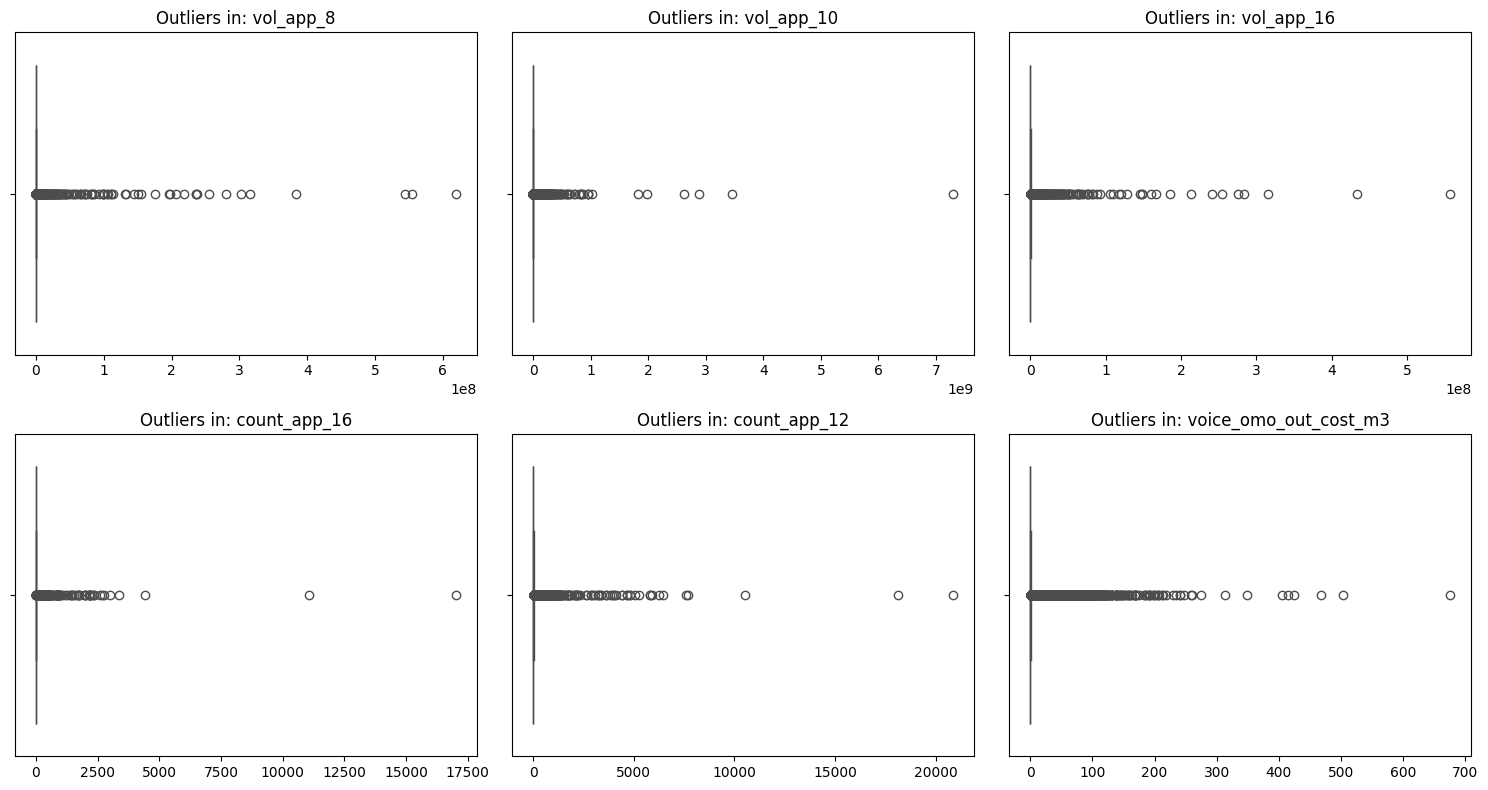

In [9]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Calculate "Outlier Score" for each column
# Score = (Max - Q3) / IQR. Higher score = more extreme outlier.
outlier_scores = []

for col in numeric_cols:
    # Skip binary columns (0/1) and target
    if df[col].nunique() <= 2 or col == 'target':
        continue
        
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    # Avoid division by zero if IQR is 0 (constant features)
    if iqr > 0:
        max_val = df[col].max()
        score = (max_val - q3) / iqr
        outlier_scores.append((col, score))

# Sort and get Top-6 most extreme features
top_outliers = sorted(outlier_scores, key=lambda x: x[1], reverse=True)[:6]
top_cols = [x[0] for x in top_outliers]

print("Top-6 Features with Extreme Outliers:")
for name, score in top_outliers:
    print(f"{name}: Max value is {int(score)}x times larger than IQR range")

# Plot Boxplots for these 6 features
plt.figure(figsize=(15, 8))
for i, col in enumerate(top_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Outliers in: {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

#### Analysis of Extreme Values

The detected outliers (max values > 8000x IQR) are primarily concentrated in **App Usage Volume (`vol_app_*`)** and **Voice Costs**.

**Business Interpretation:**
These represent **"Super Users"** - subscribers with extremely high consumption compared to the median user (who often has 0 usage for specific apps).
* **Action:** will **NOT remove** these records, as high usage is likely a strong predictor of subscription behavior.
* **Preprocessing:** We must apply **Log-Transformation** or **RobustScaler** to these features before training linear models to minimize the skewness impact.

In [10]:
df[["lt", "balance_sum"]].describe(percentiles=[0.01,0.99])

,lt,balance_sum
count,70000.000000,69993.000000
mean,0.788683,21.687550
std,0.156634,80.115933
min,0.156195,-76.626694
1%,0.325660,-1.774197
99%,0.978211,226.741130
max,1.000000,11126.709185


Extreme values are observed in usage-related variables.
Given the telecom context, these likely represent highly active users rather than data errors.
No outlier removal will be applied.


### 8. Key Features Visualization

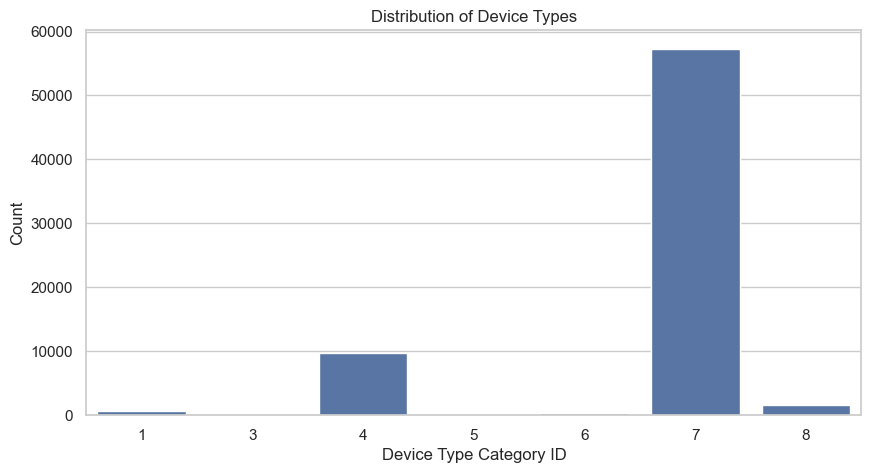

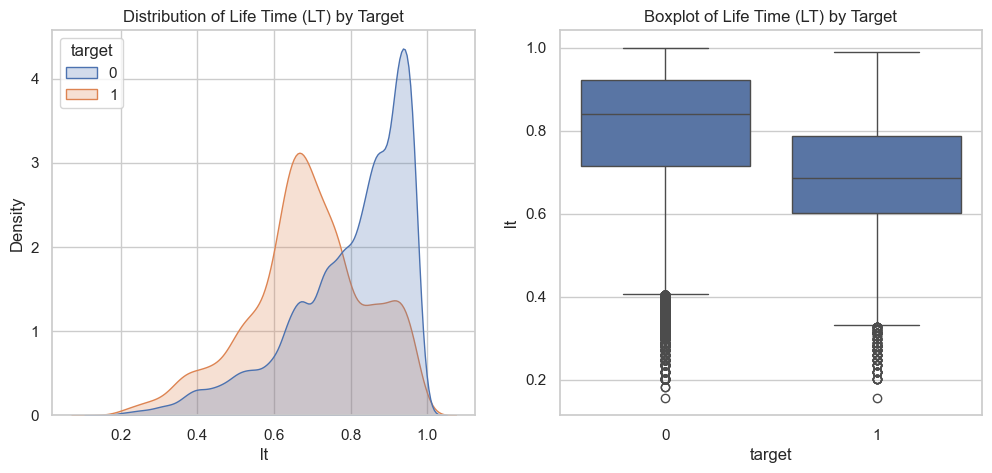

In [11]:
# Style settings
sns.set(style="whitegrid")

# Barplot for device_type
# Distribution of users by device type
plt.figure(figsize=(10, 5))
top_devices = df['device_type'].value_counts().nlargest(7).index
sns.countplot(data=df[df['device_type'].isin(top_devices)], x='device_type')
plt.title('Distribution of Device Types')
plt.xlabel('Device Type Category ID')
plt.ylabel('Count')
plt.show()

# Distribution by Target: Life Time (LT)
# We take LT because it is the feature with the highest correlation (-0.18)
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='lt', hue='target', fill=True, common_norm=False)
plt.title('Distribution of Life Time (LT) by Target')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='lt', data=df)
plt.title('Boxplot of Life Time (LT) by Target')
plt.show()

#### Visualization Insights

1.  **Device Types (Encoded):**
    * The `device_type` feature is numerical (`float/int`), but it represents distinct categories (Label Encoded).
    * The barplot shows that a few specific device IDs dominate the dataset, while others are rare.
    * **Implication:** During preprocessing, rare device IDs might need to be grouped into an "Other" category to avoid noise.

2.  **Life Time (LT) vs Target:**
    * The **Boxplot** reveals that non-subscribers (Target=0) generally have a slightly higher median Life Time compared to subscribers (Target=1).
    * This confirms the negative correlation observed earlier: newer customers are slightly more inclined to try the Music service.

### Key Findings

| Finding | Implication |
|---|---|
| 70,000 rows × 461 features | High-dimensional dataset |
| **7.6% positive class** | Strong class imbalance — use ROC-AUC, consider SMOTE or class weights |
| 62 columns with >50% missing | Structural sparsity — treat NaN as "no activity" for behavioral features |
| 19 constant columns | Zero variance — drop unconditionally |
| `manufacturer_category`: 479 unique values | High cardinality — requires special encoding |
| All Pearson correlations < 0.2 | Non-linear relationships likely — tree-based models preferred |
| `lt` has strongest signal (-0.186) | Newer customers more likely to subscribe |
| Extreme outliers in usage features | Power-law distribution typical for telecom |

### Limitations
- Pearson correlation assumes linearity — deeper analysis with Spearman/mutual information in Sprint 2
- Feature interactions not yet explored
- No feature engineering performed yet

### Next Steps (Sprint 2)
- Deep EDA: distributions per target class, feature interactions
- Spearman & mutual information feature ranking
- Handle `manufacturer_category` high cardinality
- Feature engineering: aggregate `_m1/_m2/_m3` trends, create ratio features
- Baseline model training (Logistic Regression + Random Forest)

- Most individual features show weak linear correlation with the target.
- Correlation does not imply causation.
- Non-linear relationships may exist.

Next steps:
- Data cleaning
- Handling missing values based on feature semantics
- Preprocessing
- Model training and evaluation